In [5]:
import pandas as pd
import os

# 1. Let's see where Python thinks it is currently looking
print("Current Working Directory:", os.getcwd())

# 2. Define the path relative to your main project folder
# (We don't need the full D:\ drive address anymore)
relative_path = r"Data\Raw\PK_2017-18_DHS_06272026_421_252524\PKHR71DT\PKHR71FL.DTA"

# 3. Load the dataset
df = pd.read_stata(relative_path, convert_categoricals=True)

# 4. Success check
print("Dataset Shape:", df.shape)
df.head()

Current Working Directory: d:\Public_Health_Forecasting
Dataset Shape: (14540, 4552)


,hhid,hv000,hv001,hv002,hv003,hv004,hv005,hv006,hv007,hv008,...,sh41a_01,sh41a_02,sh41a_03,sh41a_04,sh41a_05,sh41a_06,sh41a_07,sh41a_08,sh41a_09,sh41a_10
0,1 1,PK7,1,1,2,1,849785,2,2018,1418,...,neither send nor received,neither send nor received,neither send nor received,neither send nor received,NaN,NaN,NaN,NaN,NaN,NaN
1,1 2,PK7,1,2,2,1,849785,2,2018,1418,...,received money,neither send nor received,neither send nor received,received money,received money,NaN,NaN,NaN,NaN,NaN
2,1 3,PK7,1,3,3,1,849785,2,2018,1418,...,neither send nor received,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1 4,PK7,1,4,1,1,849785,2,2018,1418,...,neither send nor received,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 5,PK7,1,5,2,1,849785,2,2018,1418,...,neither send nor received,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
cols_of_interest= [
    'hv001', #The neighbour hood where the household is located
    'hv024', #the province where the household is located
    'hv025', #where it is located like urban or rural
    'hv270', #wealth category of the household rich or poor
    'hv219', #the sex of th household male or female
    'hv005'  #the weight of the household

]

df_research = df[cols_of_interest].copy()

print("Research Dataset Shape:", df_research.shape)
df_research.head()

Research Dataset Shape: (14540, 6)


,hv001,hv024,hv025,hv270,hv219,hv005
0,1,kpk,rural,poorest,male,849785
1,1,kpk,rural,poorest,male,849785
2,1,kpk,rural,poorest,male,849785
3,1,kpk,rural,poorer,female,849785
4,1,kpk,rural,poorest,male,849785


C:\Users\Harris\AppData\Local\Temp\ipykernel_15924\607384156.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_research, x='hv270', palette='viridis')


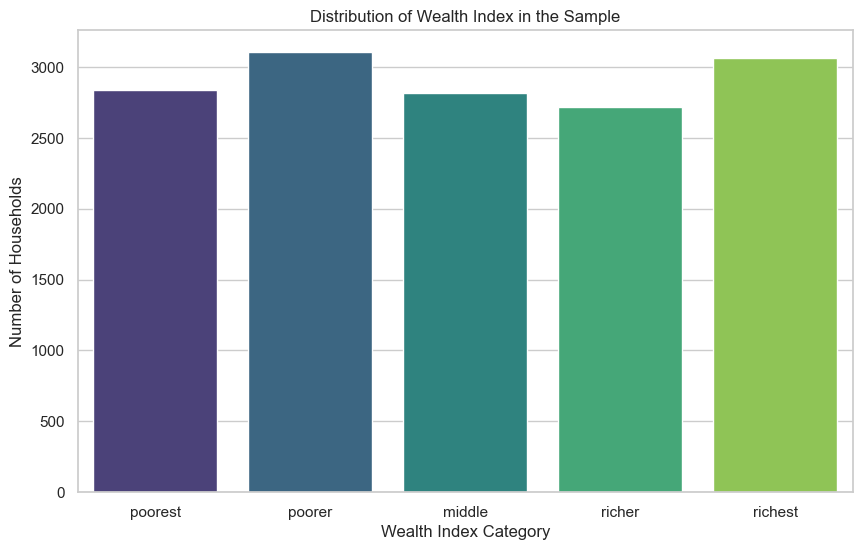

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df_research, x='hv270', palette='viridis')
plt.title('Distribution of Wealth Index in the Sample')
plt.xlabel('Wealth Index Category')
plt.ylabel('Number of Households')
plt.show()



In [11]:
cross_tab = pd.crosstab(df_research['hv270'], df['hv215'])
print("cross-tabulation of wealth vs Distance problem:")
print(cross_tab)




cross-tabulation of wealth vs Distance problem:
hv215    no roof  thatch/palm leaf  sod/grass  rustic mat  palm/bamboo  \
hv270                                                                    
poorest        4               149         64         768          455   
poorer         0                15         12         348          306   
middle         0                 4          1          80           87   
richer         0                 1          0          12           14   
richest        0                 0          0           0            1   

hv215    wood planks  cardboard  asbestos  reinforced brick cement/rcc  metal  \
hv270                                                                           
poorest          242         24         6                          365     34   
poorer           327         54         3                          918     95   
middle           167         35         8                          920    104   
richer            77        

<Figure size 1000x600 with 0 Axes>

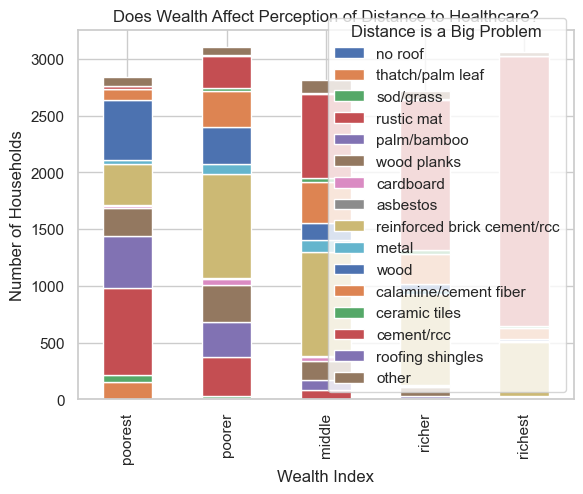

In [12]:
#visualization
plt.figure(figsize=(10,6))
cross_tab.plot(kind='bar', stacked=True)
plt.title('Does Wealth Affect Perception of Distance to Healthcare?')
plt.xlabel('Wealth Index')
plt.ylabel('Number of Households')
plt.legend(title='Distance is a Big Problem')
plt.show()

In [13]:

matching_cols = [col for col in df.columns if 'dist' in col.lower() or 'prob' in col.lower()]

print("Potential columns for distance/problems:")
print(matching_cols)

Potential columns for distance/problems:
['shdist']


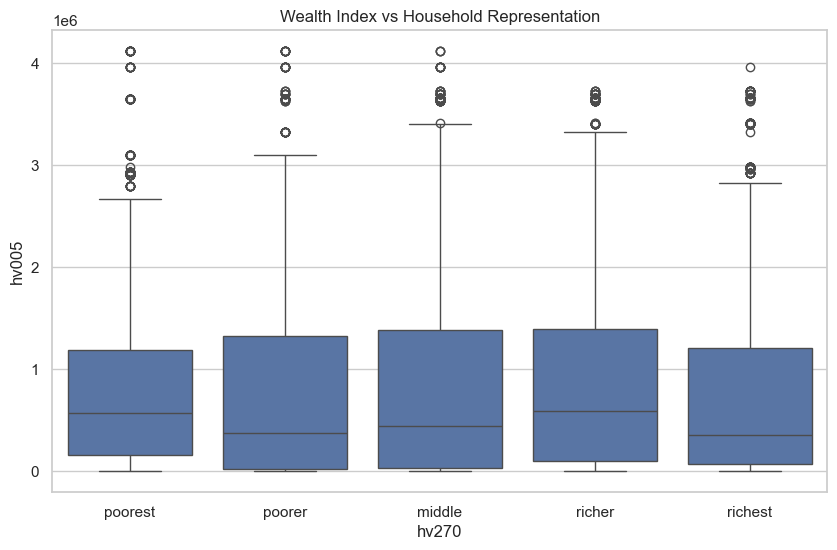

hv201    piped into dwelling  piped to yard/plot  piped to neighbor  \
hv270                                                                 
poorest                  307                 131                111   
poorer                   693                 136                113   
middle                   847                  65                 68   
richer                   843                  49                 23   
richest                  904                  28                 16   

hv201    public tap/standpipe  tube well or borehole  protected well  \
hv270                                                                  
poorest                   152                   1209             122   
poorer                    206                   1190             218   
middle                    188                   1101             125   
richer                    244                   1083              84   
richest                   210                   1049              79  

In [14]:
# Check how wealth relates to having an improved water source
# hv201 is often the code for 'Source of drinking water'
# We'll just look at the distribution first
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='hv270', y='hv005') # Using weight to see representation
plt.title('Wealth Index vs Household Representation')
plt.show()

# Let's see the counts of Water Source (hv201) by Wealth (hv270)
water_wealth = pd.crosstab(df['hv270'], df['hv201'])
print(water_wealth)

C:\Users\Harris\AppData\Local\Temp\ipykernel_15924\270698841.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['has_piped_water'] = df['hv201'].str.contains('piped', case=False, na=False)
C:\Users\Harris\AppData\Local\Temp\ipykernel_15924\270698841.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='hv270', y='has_piped_water', errorbar=None, palette='mako')


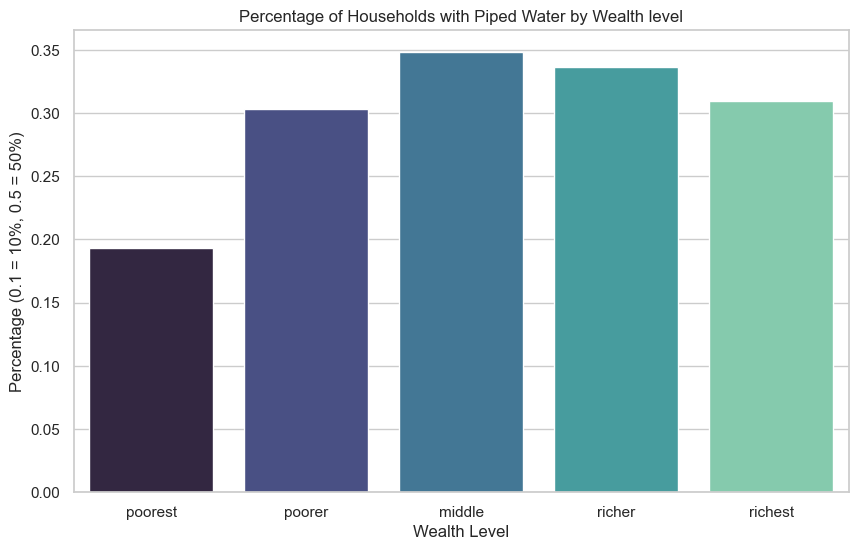

In [15]:
# 1. Check if households have "piped water" into their dwelling/yard
# We create a simple True/False column
df['has_piped_water'] = df['hv201'].str.contains('piped', case=False, na=False)

# 2. Make a simple chart comparing wealth and piped water
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='hv270', y='has_piped_water', errorbar=None, palette='mako')

# 3. Add simple labels
plt.title('Percentage of Households with Piped Water by Wealth level')
plt.xlabel('Wealth Level')
plt.ylabel('Percentage (0.1 = 10%, 0.5 = 50%)')
plt.show()

C:\Users\Harris\AppData\Local\Temp\ipykernel_15924\845837018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='hv024', y='has_piped_water', errorbar=None, palette='Set2')


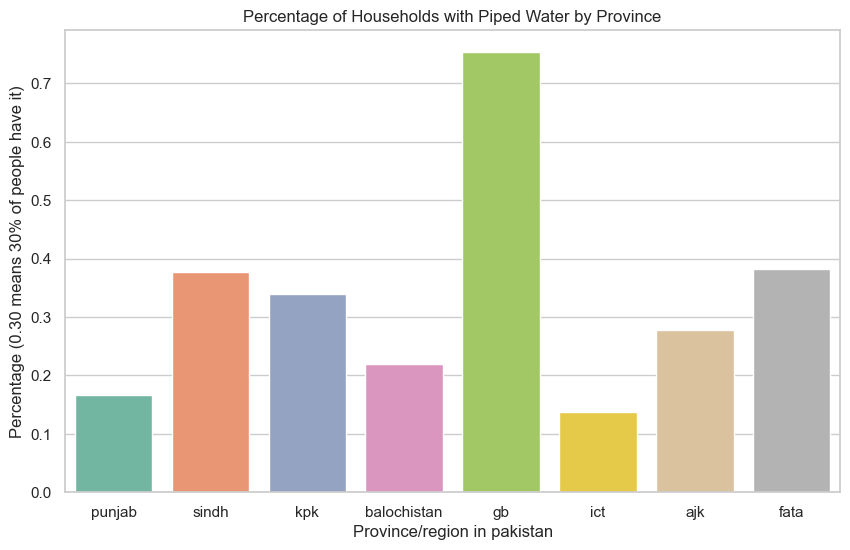

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='hv024', y='has_piped_water', errorbar=None, palette='Set2')

plt.title("Percentage of Households with Piped Water by Province")
plt.xlabel("Province/region in pakistan")
plt.ylabel("Percentage (0.30 means 30% of people have it)")
plt.show()


In [20]:
import os
import pandas as pd

# 1. Update the path to include the exact date-stamped folder DHS created today
kr_file_path = os.path.join(
    "Data", 
    "Raw", 
    "PK_2017-18_DHS_06282026_104_252524", 
    "PKKR71DT", 
    "PKKR71FL.DTA"
)

# 2. Read the Stata file into pandas
df_kr = pd.read_stata(kr_file_path, convert_categoricals=False)

# 3. Print out the basic metrics to confirm success
print("--- CHILDREN'S DATASET LOADED ---")
print(f"Total Rows (Children Surveyed): {df_kr.shape[0]}")
print(f"Total Columns (Variables Available): {df_kr.shape[1]}")

# 4. Verify our research variables are waiting for us inside
target_variables = {'v106': "Mother's Education Level", 'h11': "Child Diarrhea Status"}

print("\n--- VARIABLE VERIFICATION ---")
for var_code, var_name in target_variables.items():
    if var_code in df_kr.columns:
        print(f"✅ Verified: {var_code} ({var_name}) is present.")
    else:
        print(f"❌ Warning: Could not find {var_code} in this dataset.")


--- CHILDREN'S DATASET LOADED ---
Total Rows (Children Surveyed): 12708
Total Columns (Variables Available): 1186

--- VARIABLE VERIFICATION ---
✅ Verified: v106 (Mother's Education Level) is present.
✅ Verified: h11 (Child Diarrhea Status) is present.


In [21]:

print("--- Raw Counts for Mother's Education (v106) ---")
print(df_kr['v106'].value_counts().sort_index())

print("\n" + "="*40 + "\n") 

print("--- Raw Counts for Child Diarrhea Status (h11) ---")
print(df_kr['h11'].value_counts().sort_index())

--- Raw Counts for Mother's Education (v106) ---
v106
0    6532
1    1717
2    2637
3    1822
Name: count, dtype: int64


--- Raw Counts for Child Diarrhea Status (h11) ---
h11
0.0    9840
2.0    2107
8.0      38
Name: count, dtype: int64


In [22]:

df_clean = df_kr[df_kr['h11'] != 8.0].copy()


df_clean = df_clean.dropna(subset=['h11', 'v106'])

# 3. Standardize the illness column into a true binary format (0 and 1)
# Currently: 0.0 = Healthy, 2.0 = Sick
# Target:    0 = Healthy, 1 = Sick (This is what logistic regression expects)
df_clean['is_sick'] = df_clean['h11'].replace({2.0: 1, 0.0: 0})

# 4. Print out our final, clean numbers to verify everything worked perfectly
print("--- DATA PRE-PROCESSING COUNTDOWN COMPLETE ---")
print(f"Remaining clean records for analysis: {df_clean.shape[0]} children")

print("\n--- Cleaned Mother's Education Levels (v106) ---")
# 0 = None, 1 = Primary, 2 = Secondary, 3 = Higher
print(df_clean['v106'].value_counts().sort_index())

print("\n--- Cleaned Child Illness Status (is_sick) ---")
# 0 = Child is Healthy, 1 = Child is Sick
print(df_clean['is_sick'].value_counts().sort_index())

--- DATA PRE-PROCESSING COUNTDOWN COMPLETE ---
Remaining clean records for analysis: 11947 children

--- Cleaned Mother's Education Levels (v106) ---
v106
0    6086
1    1603
2    2493
3    1765
Name: count, dtype: int64

--- Cleaned Child Illness Status (is_sick) ---
is_sick
0.0    9840
1.0    2107
Name: count, dtype: int64


In [23]:
import statsmodels.formula.api as smf


trends = df_clean.groupby('v106')['is_sick'].mean() * 100

print("--- 1. REAL-WORLD HEALTH TRENDS ---")
print(f"Mothers with No Education (0):    {trends.get(0, 0):.2f}% of children sick")
print(f"Mothers with Primary (1):         {trends.get(1, 0):.2f}% of children sick")
print(f"Mothers with Secondary (2):       {trends.get(2, 0):.2f}% of children sick")
print(f"Mothers with Higher Ed (3):       {trends.get(3, 0):.2f}% of children sick")
print("\n" + "="*60 + "\n")

model = smf.logit("is_sick ~ C(v106)", data=df_clean)
results = model.fit()

print("\n--- 2. ADVANCED STATISTICAL MODEL SUMMARY ---")
print(results.summary())


--- 1. REAL-WORLD HEALTH TRENDS ---
Mothers with No Education (0):    16.96% of children sick
Mothers with Primary (1):         20.15% of children sick
Mothers with Secondary (2):       18.57% of children sick
Mothers with Higher Ed (3):       16.37% of children sick


Optimization terminated successfully.
         Current function value: 0.465324
         Iterations 5

--- 2. ADVANCED STATISTICAL MODEL SUMMARY ---
                           Logit Regression Results                           
Dep. Variable:                is_sick   No. Observations:                11947
Model:                          Logit   Df Residuals:                    11943
Method:                           MLE   Df Model:                            3
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                0.001091
Time:                        13:59:32   Log-Likelihood:                -5559.2
converged:                       True   LL-Null:                       -5565.3
Covariance Type:            

In [24]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

df_mv = df_clean[
    (df_clean["v113"] < 98) & (df_clean["v190"].notna())
].copy()


mv_model = smf.logit("is_sick ~ C(v106) + C(v190) + C(v113)", data=df_mv)
mv_results = mv_model.fit()

print("\n" + "=" * 50)
print("--- MULTIVARIABLE LOGISTIC REGRESSION MODEL FITTED ---")
print(f"Total sample size used after controls: {df_mv.shape[0]} children")
print("=" * 50)


model_odds = pd.DataFrame(
    {
        "Odds Ratio (OR)": np.exp(mv_results.params),
        "Lower CI (2.5%)": np.exp(mv_results.conf_int()[0]),
        "Upper CI (97.5%)": np.exp(mv_results.conf_int()[1]),
        "p-value": mv_results.pvalues,
    }
)

print("\n--- FINAL HEALTH ODDS RATIOS FOR RESEARCH INSIGHTS ---")
education_rows = [r for r in model_odds.index if "v106" in r]
print(model_odds.loc[education_rows].round(4))

Optimization terminated successfully.
         Current function value: 0.464053
         Iterations 6

--- MULTIVARIABLE LOGISTIC REGRESSION MODEL FITTED ---
Total sample size used after controls: 11947 children

--- FINAL HEALTH ODDS RATIOS FOR RESEARCH INSIGHTS ---
              Odds Ratio (OR)  Lower CI (2.5%)  Upper CI (97.5%)  p-value
C(v106)[T.1]           1.2477           1.0785            1.4434   0.0029
C(v106)[T.2]           1.1585           1.0084            1.3309   0.0376
C(v106)[T.3]           1.0167           0.8558            1.2079   0.8505


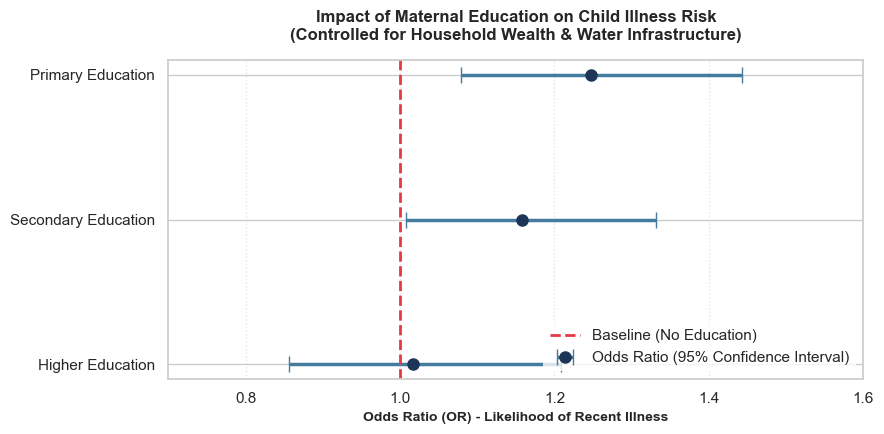

In [25]:
import matplotlib.pyplot as plt

# 1. Prepare the data from your regression output
labels = ['Primary Education', 'Secondary Education', 'Higher Education']
odds_ratios = [1.2477, 1.1585, 1.0167]
lower_ci = [1.0785, 1.0084, 0.8558]
upper_ci = [1.4434, 1.3309, 1.2079]

# Calculate the length of the error bars on the left and right sides
error_left = [or_val - low for or_val, low in zip(odds_ratios, lower_ci)]
error_right = [up - or_val for or_val, up in zip(odds_ratios, upper_ci)]
asymmetric_error = [error_left, error_right]

# 2. Initialize the plot layout
plt.figure(figsize=(9, 4.5), dpi=100)

# 3. Plot the Odds Ratios as dots with horizontal confidence interval lines
plt.errorbar(odds_ratios, labels, xerr=asymmetric_error, fmt='o', color='#1d3557',
             ecolor='#457b9d', elinewidth=2.5, capsize=6, markersize=8, 
             label='Odds Ratio (95% Confidence Interval)')

# 4. Add the crucial baseline reference line (No Education = 1.0)
plt.axvline(x=1.0, color='#e63946', linestyle='--', linewidth=2, label='Baseline (No Education)')

# 5. Make the chart look professional and clean
plt.title("Impact of Maternal Education on Child Illness Risk\n(Controlled for Household Wealth & Water Infrastructure)", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Odds Ratio (OR) - Likelihood of Recent Illness", fontsize=10, fontweight='bold')
plt.xlim(0.7, 1.6)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.gca().invert_yaxis() # Puts Primary at the top and Higher at the bottom

# 6. Display the beautiful visual
plt.tight_layout()
plt.show()

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import patsy


y, X = patsy.dmatrices("is_sick ~ C(v106) + C(v190) + C(v113)", data=df_mv, return_type='dataframe')


vif_data = pd.DataFrame()
vif_data["Feature Variable"] = X.columns
vif_data["VIF Score"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


print("="*60)
print("--- 1. MULTICOLLINEARITY DIAGNOSTIC (VIF) ---")
print("="*60)

print(vif_data[vif_data["Feature Variable"] != "Intercept"].head(10).round(3))
print("\n💡 Rule of Thumb: VIF scores below 5.0 mean zero multicollinearity issues!")

print("\n" + "="*60)
print("--- 2. MODEL FIT DIAGNOSTICS ---")
print("="*60)
print(f"Log-Likelihood:             {mv_results.llf:.2f}")
print(f"Pseudo R-squared (McFadden): {mv_results.prsquared:.4f}")

--- 1. MULTICOLLINEARITY DIAGNOSTIC (VIF) ---
   Feature Variable  VIF Score
1      C(v106)[T.1]      1.191
2      C(v106)[T.2]      1.463
3      C(v106)[T.3]      1.638
4      C(v190)[T.2]      1.655
5      C(v190)[T.3]      1.801
6      C(v190)[T.4]      1.963
7      C(v190)[T.5]      2.415
8     C(v113)[T.12]      1.116
9     C(v113)[T.13]      1.097
10    C(v113)[T.14]      1.197

💡 Rule of Thumb: VIF scores below 5.0 mean zero multicollinearity issues!

--- 2. MODEL FIT DIAGNOSTICS ---
Log-Likelihood:             -5544.04
Pseudo R-squared (McFadden): 0.0038
